In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Installations and Imports


In [17]:
!pip install librosa transformers torch torchaudio scikit-learn audiomentations umap-learn pyroomacoustics plotly

In [18]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import torchaudio
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from tqdm import tqdm
from audiomentations import Compose, AddGaussianNoise, RoomSimulator, LowPassFilter
from scipy.spatial.distance import cosine, euclidean

from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA

from transformers import Wav2Vec2Processor, Wav2Vec2Model

In [19]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(DEVICE)
model.eval()

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

# Data Loading


In [20]:
def collect_files(base_path, folders, label):
    data = []

    for folder in folders:
        folder_path = os.path.join(base_path, folder)

        if not os.path.exists(folder_path):
            print("Missing folder:", folder_path)
            continue

        for root, _, files in os.walk(folder_path):
            for file in files:
                if file.lower().endswith(('.wav', '.mp3', '.m4a')):
                    full_path = os.path.join(root, file)
                    data.append((full_path, label))

    return data

In [21]:
BASE_PATH = "/content/drive/MyDrive/IAPC Project/Pre - Processed Dataset"

folders = os.listdir(BASE_PATH)
print("Detected folders:", folders)

AI_FOLDERS = [f for f in folders if f.lower().startswith("ai")]
HUMAN_FOLDERS = [f for f in folders if "human" in f.lower()]

print("AI folders:", AI_FOLDERS)
print("Human folders:", HUMAN_FOLDERS)

ai_data = collect_files(BASE_PATH, AI_FOLDERS, 1)
human_data = collect_files(BASE_PATH, HUMAN_FOLDERS, 0)

dataset = ai_data + human_data

df = pd.DataFrame(dataset, columns=["file_path", "label"])

print("Total:", len(df))
print("AI:", sum(df.label == 1))
print("Human:", sum(df.label == 0))

Detected folders: ['AI Voices', 'Human Voices', 'preprocessed_audio_dataset.csv']
AI folders: ['AI Voices']
Human folders: ['Human Voices']
Total: 1768
AI: 822
Human: 946


# Feature Extraction Pipeline

In [22]:

def load_audio_fast(file_path, target_sr=16000, target_duration_sec=30):
    """
    Loads, converts to mono, resamples, normalizes, and pads/truncates audio
    using torchaudio for maximum speed.
    """
    try:
        # 1. Load the audio file natively into a PyTorch tensor
        waveform, sample_rate = torchaudio.load(file_path)

        # 2. Convert to Mono if it's Stereo (average across the channel dimension)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # 3. Resample if necessary (torchaudio resampling is highly optimized)
        if sample_rate != target_sr:
            resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=target_sr)
            waveform = resampler(waveform)

        # 4. Squeeze out the channel dimension so it's a flat 1D array
        waveform = waveform.squeeze(0)

        # 5. Convert to a 32-bit float NumPy array (required for audiomentations & librosa)
        audio_np = waveform.numpy().astype(np.float32)

        # 6. Normalize loudness (keeps your data standardized)
        audio_np = audio_np / (np.max(np.abs(audio_np)) + 1e-6)

        # 7. ENFORCE EXACT 30-SECOND LENGTH (Padding and Truncating)
        target_length = target_sr * target_duration_sec
        current_length = len(audio_np)

        if current_length < target_length:
            # Pad with digital silence (zeros) at the end of the array
            pad_amount = target_length - current_length
            audio_np = np.pad(audio_np, (0, pad_amount), mode='constant', constant_values=0.0)

        elif current_length > target_length:
            # Truncate anything that spills over 30 seconds
            audio_np = audio_np[:target_length]

        return audio_np

    except Exception as e:
        print(f"Failed to load {file_path}: {e}")
        return None

In [23]:
def extract_wav2vec(audio):
    inputs = processor(audio, sampling_rate=16000, return_tensors="pt", padding=True).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    embeddings = outputs.last_hidden_state.squeeze(0)

    mean = torch.mean(embeddings, dim=0)
    std = torch.std(embeddings, dim=0)

    pooled = torch.cat([mean, std]).cpu().numpy()

    return pooled

In [24]:
def extract_handcrafted(audio, sr=16000):

    # MFCC
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    # Spectral
    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))

    # Pitch (FIXED NaN issue)
    pitch = librosa.yin(audio, fmin=50, fmax=300)
    pitch = pitch[~np.isnan(pitch)]

    pitch_mean = np.mean(pitch) if len(pitch) > 0 else 0
    pitch_std = np.std(pitch) if len(pitch) > 0 else 0

    features = np.hstack([
        mfcc_mean, mfcc_std,
        centroid, bandwidth, rolloff,
        pitch_mean, pitch_std
    ])

    return features

In [25]:

# Define the "Acoustic Degrader" pipeline
# We apply these randomly to simulate real-world recording conditions
degrader = Compose([
    # 1. Inject a subtle noise floor (simulates a microphone in a quiet room)
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.005, p=1.0),

    # 2. Add realistic room reverberation (simulates bouncing off walls)
    RoomSimulator(p=0.8),

    # 3. Simulate MP3/Streaming high-frequency cutoff
    # Podcasts compressed on Spotify/YouTube usually lose frequencies above 7-8kHz
    LowPassFilter(min_cutoff_freq=6000, max_cutoff_freq=8000, p=1.0)
])

def extract_features(file_path, label):
    try:
        # Load audio using your existing function
        audio = load_audio_fast(file_path)

        # APPLY FIX HERE: Only degrade the AI voices (label == 1)
        # to bring their quality down to the level of the human podcast recordings.
        if label == 1:
            # audiomentations expects 32-bit float
            audio = audio.astype(np.float32)
            audio = degrader(samples=audio, sample_rate=16000)

        # Proceed with your normal pipeline
        wav2vec_feat = extract_wav2vec(audio)
        handcrafted_feat = extract_handcrafted(audio)

        features = np.hstack([wav2vec_feat, handcrafted_feat])

        if np.isnan(features).any() or np.isinf(features).any():
            return None

        return features

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [26]:

# --- SETTINGS ---
# Since your clips are 30 seconds long, they take up a lot of GPU VRAM.
# Start with a batch size of 4 or 8. If Colab crashes with "CUDA Out of Memory", lower it to 4.
BATCH_SIZE = 12

X_batched = []
y_batched = []

# Convert dataframe to lists for easy slicing
file_paths = df["file_path"].tolist()
labels = df["label"].tolist()

print(f"Extracting features using GPU batching (Batch Size: {BATCH_SIZE})...")

for i in tqdm(range(0, len(file_paths), BATCH_SIZE)):
    # 1. Slice the current batch
    batch_paths = file_paths[i : i + BATCH_SIZE]
    batch_labels = labels[i : i + BATCH_SIZE]

    batch_audio_arrays = []
    batch_handcrafted_feats = []
    valid_labels = []

    # 2. CPU Phase: Load, Degrade, and Handcrafted Extraction
    for path, label in zip(batch_paths, batch_labels):
        audio = load_audio_fast(path)

        if audio is None:
            continue

        # Apply degradation to AI
        if label == 1:
            audio = degrader(samples=audio, sample_rate=16000)

        # Extract librosa features immediately
        hc_feat = extract_handcrafted(audio)
        if hc_feat is None or np.isnan(hc_feat).any():
            continue

        batch_audio_arrays.append(audio)
        batch_handcrafted_feats.append(hc_feat)
        valid_labels.append(label)

    # Skip if entire batch failed
    if len(batch_audio_arrays) == 0:
        continue

    # 3. GPU Phase: Wav2Vec2 Batch Processing
    # The processor automatically pads shorter audio clips with 0s so they fit perfectly into a tensor matrix
    inputs = processor(batch_audio_arrays, sampling_rate=16000, return_tensors="pt", padding=True).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    # hidden_states shape is: (batch_size, sequence_length, hidden_dim)
    hidden_states = outputs.last_hidden_state

    # We take the mean and std across the sequence length (dim=1) for the whole batch at once!
    mean_embeds = torch.mean(hidden_states, dim=1) # Shape: (batch_size, 768)
    std_embeds = torch.std(hidden_states, dim=1)   # Shape: (batch_size, 768)

    # Concatenate mean and std -> Shape: (batch_size, 1536)
    wav2vec_feats = torch.cat([mean_embeds, std_embeds], dim=1).cpu().numpy()

    # 4. Combine GPU features with CPU features
    hc_feats_np = np.array(batch_handcrafted_feats)
    final_combined_features = np.hstack([wav2vec_feats, hc_feats_np])

    # Store results
    X_batched.extend(final_combined_features)
    y_batched.extend(valid_labels)

# 5. Finalize Arrays
X = np.array(X_batched)
y = np.array(y_batched)

np.save("X_features.npy", X)
np.save("y_labels.npy", y)

print(f"\nFinal feature matrix shape: {X.shape}")

Extracting features using GPU batching (Batch Size: 12)...


100%|██████████| 148/148 [41:42<00:00, 16.91s/it]


Final feature matrix shape: (1768, 1567)


# Feature Visualization


--- Computing t-SNE for Perplexity = 2 ---
Computing Wav2Vec2...
Computing Handcrafted features...

--- Computing t-SNE for Perplexity = 30 ---
Computing Wav2Vec2...
Computing Handcrafted features...

--- Computing t-SNE for Perplexity = 50 ---
Computing Wav2Vec2...
Computing Handcrafted features...


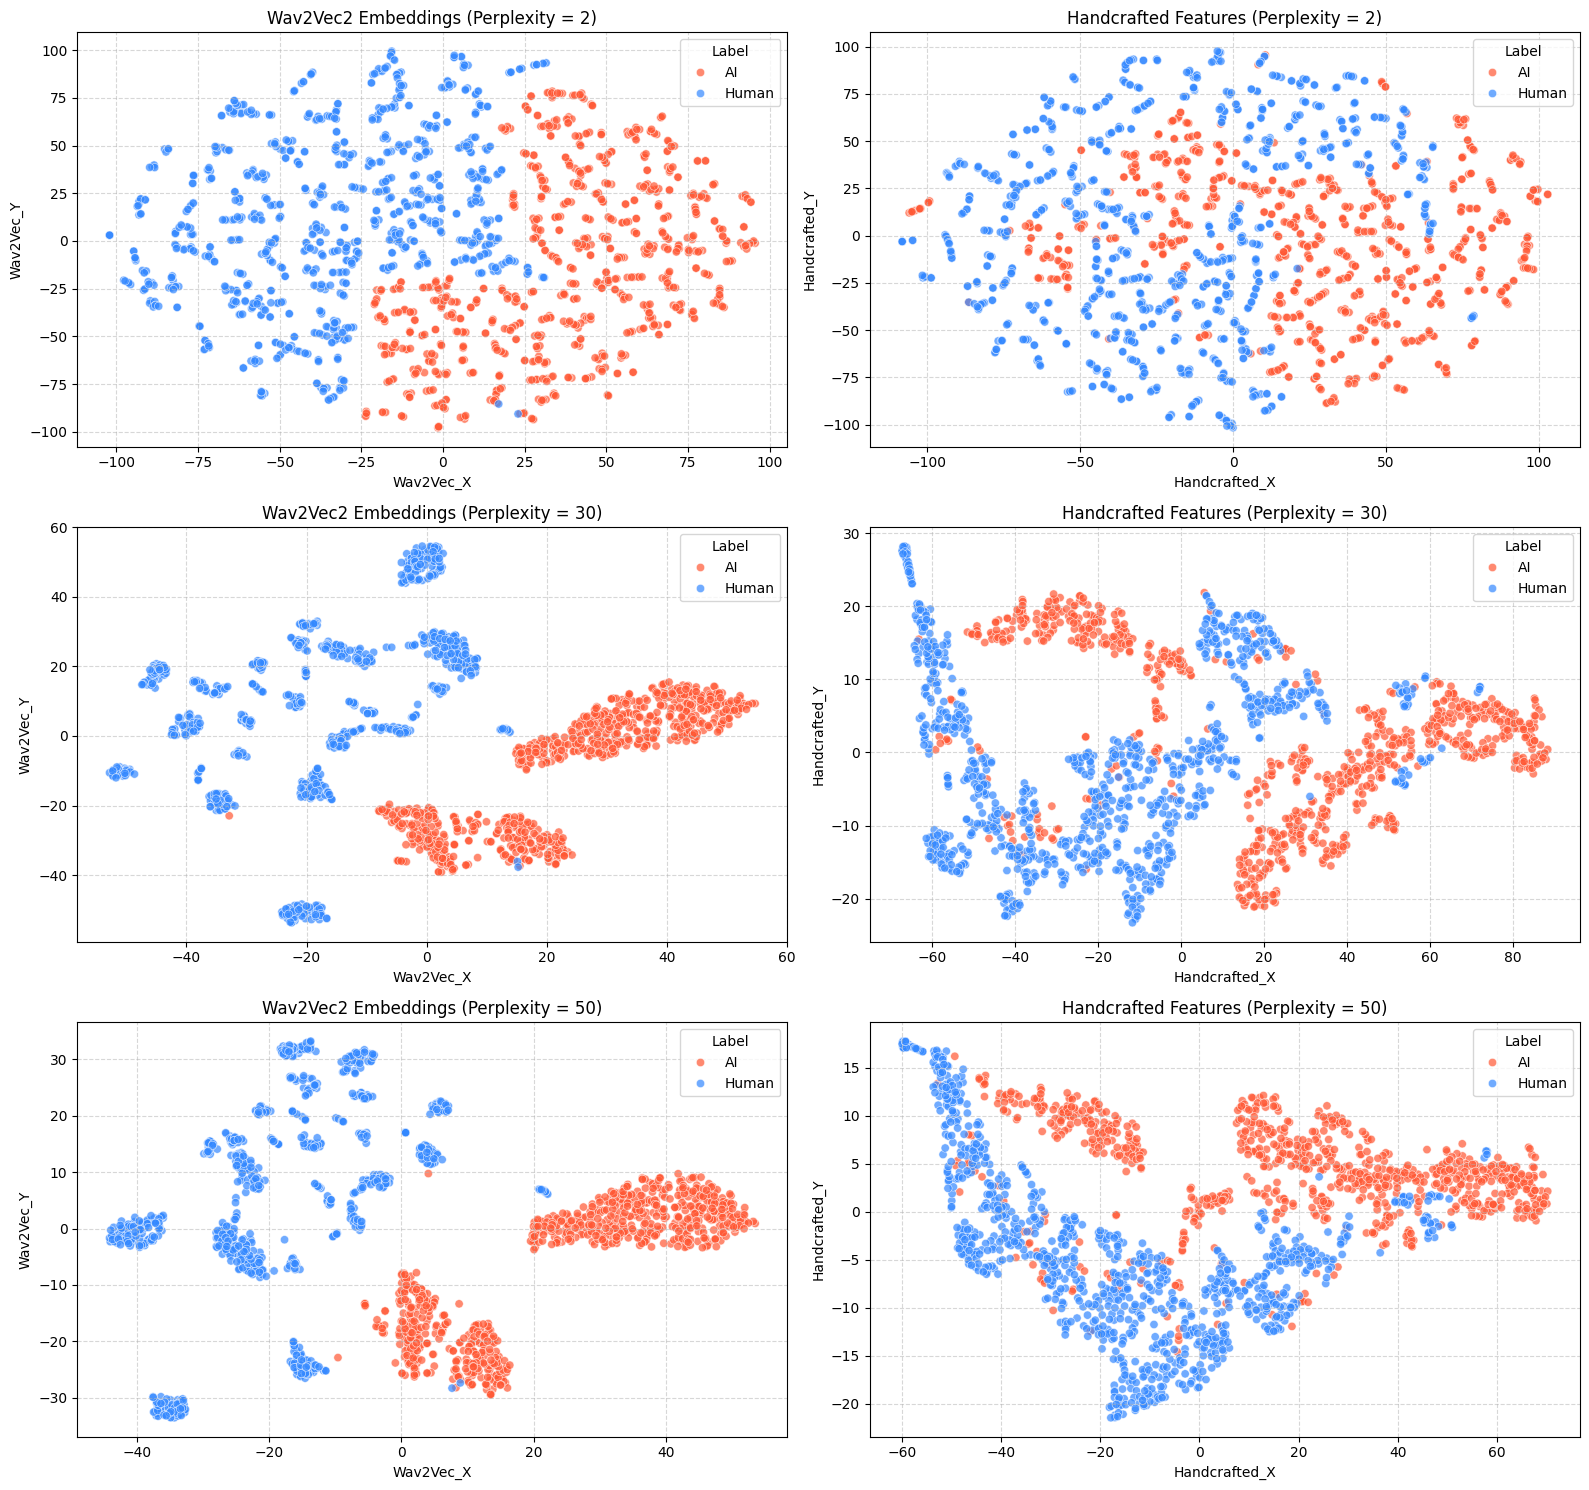

In [27]:

# 1. Separate the features based on your concatenation logic
# Wav2Vec2 features are the first 1536 (768 mean + 768 std)
# Handcrafted features are the remaining 31
X_wav2vec = X[:, :1536]
X_handcrafted = X[:, 1536:]

perplexities = [2, 30, 50]

# Create the figure OUTSIDE the loop.
# 3 rows (for 3 perplexities), 2 columns (Wav2Vec2 vs Handcrafted)
# We dynamically set the height to 5 * the number of perplexities so it doesn't get squished
fig, axes = plt.subplots(len(perplexities), 2, figsize=(16, 5 * len(perplexities)))

# Use enumerate to automatically keep track of the row index 'i'
for i, perp in enumerate(perplexities):
    print(f"\n--- Computing t-SNE for Perplexity = {perp} ---")

    # 2. Initialize t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)

    # 3. Fit and transform the features
    print("Computing Wav2Vec2...")
    X_wav2vec_2d = tsne.fit_transform(X_wav2vec)

    print("Computing Handcrafted features...")
    X_handcrafted_2d = tsne.fit_transform(X_handcrafted)

    # 4. Create a DataFrame for easy plotting
    df_viz = pd.DataFrame({
        'Wav2Vec_X': X_wav2vec_2d[:, 0],
        'Wav2Vec_Y': X_wav2vec_2d[:, 1],
        'Handcrafted_X': X_handcrafted_2d[:, 0],
        'Handcrafted_Y': X_handcrafted_2d[:, 1],
        'Label': ['AI' if label == 1 else 'Human' for label in y]
    })

    # 5. Plotting on the correct subplot

    # Plot Wav2Vec2 (Left Column: index 0)
    sns.scatterplot(
        data=df_viz, x='Wav2Vec_X', y='Wav2Vec_Y',
        hue='Label', palette={'AI': '#FF5733', 'Human': '#3388FF'},
        alpha=0.7, ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Wav2Vec2 Embeddings (Perplexity = {perp})')
    axes[i, 0].grid(True, linestyle='--', alpha=0.5)

    # Plot Handcrafted (Right Column: index 1)
    sns.scatterplot(
        data=df_viz, x='Handcrafted_X', y='Handcrafted_Y',
        hue='Label', palette={'AI': '#FF5733', 'Human': '#3388FF'},
        alpha=0.7, ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Handcrafted Features (Perplexity = {perp})')
    axes[i, 1].grid(True, linestyle='--', alpha=0.5)

# Adjust spacing and display the final massive plot
plt.tight_layout()
plt.show()


--- Computing t-SNE for Perplexity = 2 ---
Computing combined feature embeddings...

--- Computing t-SNE for Perplexity = 30 ---
Computing combined feature embeddings...

--- Computing t-SNE for Perplexity = 50 ---
Computing combined feature embeddings...


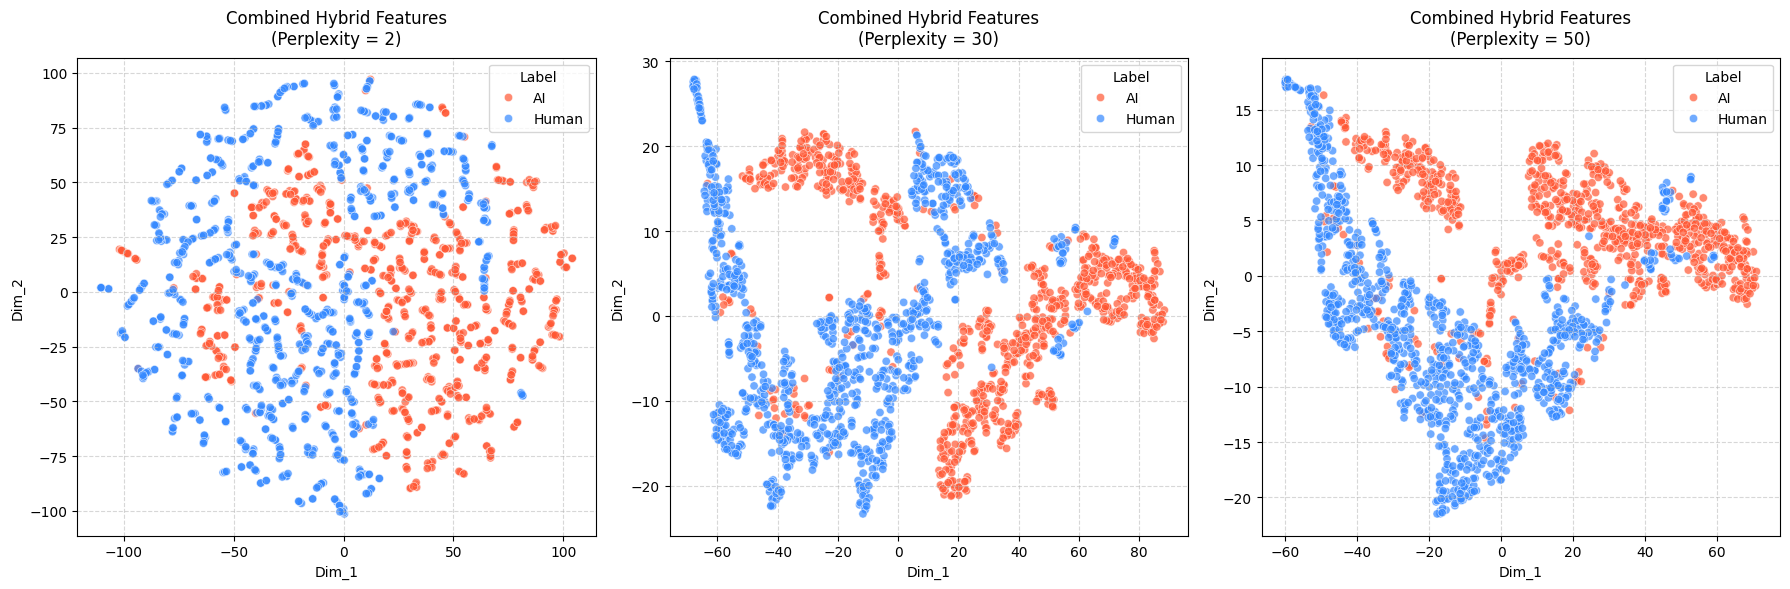

In [28]:
perplexities = [2, 30, 50]

# Create the figure.
# 1 row, and as many columns as there are perplexities (3 in this case)
fig, axes = plt.subplots(1, len(perplexities), figsize=(6 * len(perplexities), 6))

for i, perp in enumerate(perplexities):
    print(f"\n--- Computing t-SNE for Perplexity = {perp} ---")

    # 1. Initialize t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)

    # 2. Fit and transform the ENTIRE combined feature matrix (X)
    print("Computing combined feature embeddings...")
    X_2d = tsne.fit_transform(X)

    # 3. Create a DataFrame for easy plotting
    df_viz = pd.DataFrame({
        'Dim_1': X_2d[:, 0],
        'Dim_2': X_2d[:, 1],
        'Label': ['AI' if label == 1 else 'Human' for label in y]
    })

    # 4. Plotting on the correct subplot (axes is now a 1D array)
    sns.scatterplot(
        data=df_viz, x='Dim_1', y='Dim_2',
        hue='Label', palette={'AI': '#FF5733', 'Human': '#3388FF'},
        alpha=0.7, ax=axes[i]
    )

    axes[i].set_title(f'Combined Hybrid Features\n(Perplexity = {perp})', fontsize=12, pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Adjust spacing and display the final plot
plt.tight_layout()
plt.show()

In [29]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Scale the data FIRST (Critical for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Apply PCA
# n_components=0.95 means "keep 95% of the variance/information"
print("Applying PCA...")
pca = PCA(n_components=0.95, random_state=42)

# Fit PCA on training data, then transform both train and test sets
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original dimensions: {X_train_scaled.shape[1]}")
print(f"New dimensions after PCA: {X_train_pca.shape[1]}")



# Calculate Silhouette Score on the PCA data (NOT the 2D UMAP/t-SNE data!)
# This proves the mathematical distance in your actual feature space.
sil_score = silhouette_score(X_train_pca, y_train)

print(f"Silhouette Score: {sil_score:.4f}")
# A score above 0.5 is very strong for high-dimensional audio data.
# A score above 0.25 is acceptable and proves the clusters are real.

Applying PCA...
Original dimensions: 1567
New dimensions after PCA: 84
Silhouette Score: 0.2769


Computing UMAP... this is usually faster than t-SNE!


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


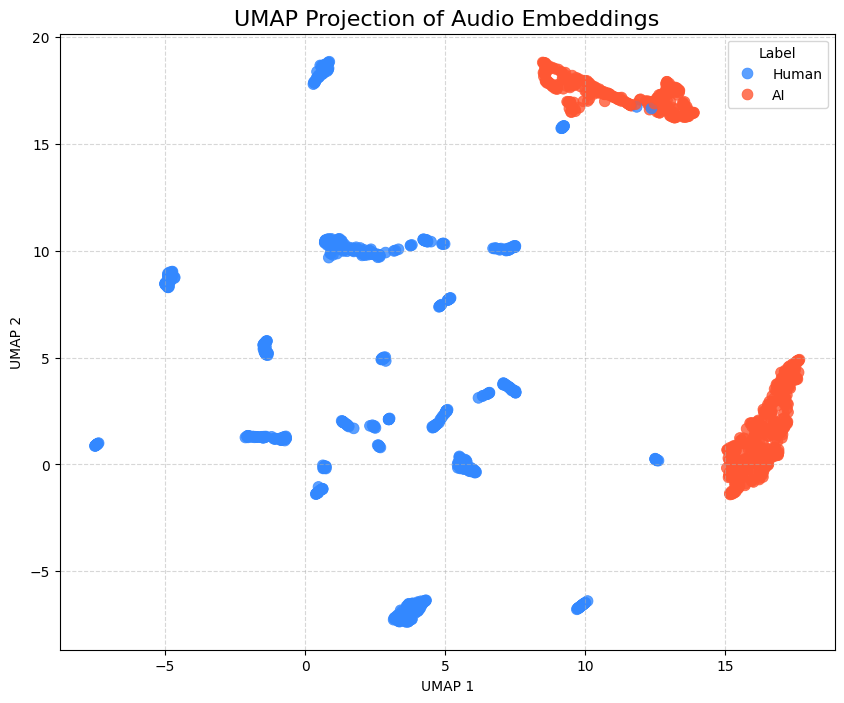

In [30]:
print("Computing UMAP... this is usually faster than t-SNE!")

# Initialize UMAP
# n_neighbors controls how it balances local vs global structure (15-50 is good)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)

# Fit and transform the scaled data (Using your PCA-reduced data is best)
X_umap = reducer.fit_transform(X_train_pca)

# Create DataFrame for plotting
df_umap = pd.DataFrame({
    'UMAP 1': X_umap[:, 0],
    'UMAP 2': X_umap[:, 1],
    'Label': ['AI' if label == 1 else 'Human' for label in y_train]
})

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_umap, x='UMAP 1', y='UMAP 2',
    hue='Label', palette={'AI': '#FF5733', 'Human': '#3388FF'},
    s=60, alpha=0.8, edgecolor=None
)

plt.title('UMAP Projection of Audio Embeddings', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


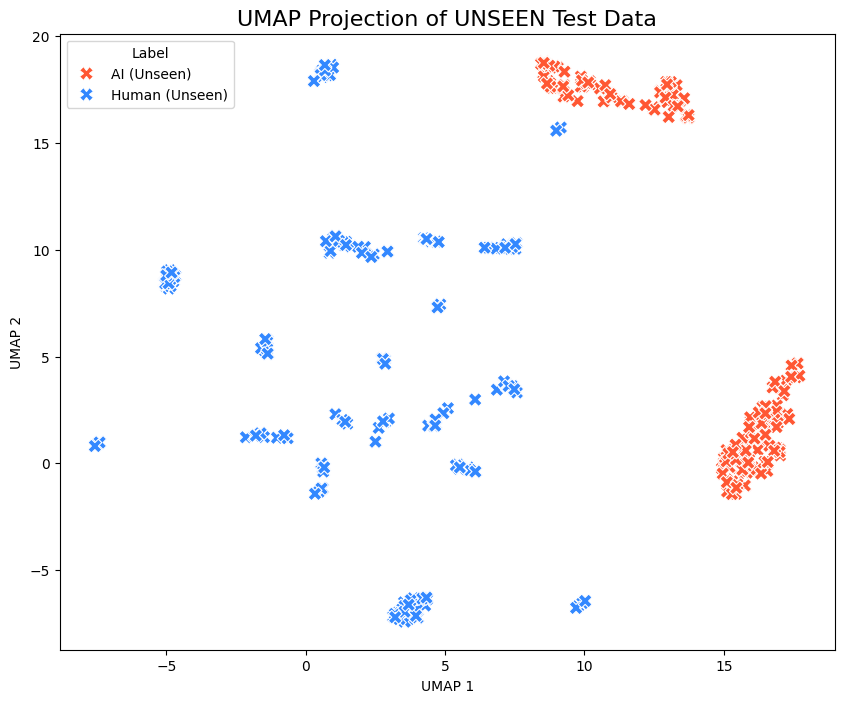

In [31]:

# 1. Fit UMAP ONLY on the training data
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_train_umap = reducer.fit_transform(X_train_pca)

# 2. Transform the unseen Test data into the same space
X_test_umap = reducer.transform(X_test_pca)

# 3. Plotting the Test Data
df_test_umap = pd.DataFrame({
    'UMAP 1': X_test_umap[:, 0],
    'UMAP 2': X_test_umap[:, 1],
    'Label': ['AI (Unseen)' if label == 1 else 'Human (Unseen)' for label in y_test]
})

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_test_umap, x='UMAP 1', y='UMAP 2',
    hue='Label', palette={'AI (Unseen)': '#FF5733', 'Human (Unseen)': '#3388FF'},
    marker='X', s=100 # Using X markers to denote test data
)
plt.title('UMAP Projection of UNSEEN Test Data', fontsize=16)
plt.show()

In [32]:


# 1. Compress Wav2Vec2 down to exactly 3 dimensions for 3D plotting
pca_3d = PCA(n_components=4)
X_wav2vec_3d = pca_3d.fit_transform(X_wav2vec)

# 2. Extract clean filenames from your original dataframe
filenames = [os.path.basename(path) for path in df['file_path']]

# 3. Create the updated DataFrame
df_3d = pd.DataFrame({
    'Filename': filenames,  # <-- Added the filenames here
    'Component 0': X_wav2vec_3d[:, 0],
    'Component 1': X_wav2vec_3d[:, 1],
    'Component 3': X_wav2vec_3d[:, 3],
    'Label': ['AI' if label == 1 else 'Human' for label in y]
})

# 4. Plot interactive 3D Graph
fig = px.scatter_3d(
    df_3d, x='Component 0', y='Component 1', z='Component 3',
    color='Label',
    hover_name='Filename',  # <-- This tells Plotly to show the filename when hovering!
    color_discrete_map={'AI': 'red', 'Human': 'blue'},
    opacity=0.7,
    title="3D PCA Visualization of Wav2Vec2 Embeddings"
)

# Render the widget
fig.update_traces(marker=dict(size=4))
fig.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Train a fast Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_pca, y_train)

# Get the top 5 most important PCA components driving the separation
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top 5 components driving the separation:")
for i in range(5):
    print(f"PCA Component {indices[i]}: {importances[indices[i]]:.4f} importance")

Top 5 components driving the separation:
PCA Component 0: 0.2022 importance
PCA Component 3: 0.1503 importance
PCA Component 1: 0.1106 importance
PCA Component 2: 0.0674 importance
PCA Component 5: 0.0578 importance


# SVM Training

In [34]:
# model = SVC(kernel='rbf', probability=True, class_weight='balanced')

# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# print(classification_report(y_test, y_pred))

# 3. Train the SVM on the newly compressed data
print("\nTraining SVM...")
svm_classifier = SVC(kernel='rbf', probability=True, class_weight='balanced')
svm_classifier.fit(X_train_pca, y_train)

# 4. Predict and Evaluate
y_pred = svm_classifier.predict(X_test_pca)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Training SVM...

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       189
           1       0.99      0.99      0.99       165

    accuracy                           0.99       354
   macro avg       0.99      0.99      0.99       354
weighted avg       0.99      0.99      0.99       354



In [35]:

# 1. Separate your PCA-compressed data by class
# Assuming your variables from the training step are X_train_pca and y_train
ai_vectors = X_train_pca[y_train == 1]
human_vectors = X_train_pca[y_train == 0]

# 2. Calculate the Centroids (the mathematical "center" of each population)
ai_centroid = np.mean(ai_vectors, axis=0)
human_centroid = np.mean(human_vectors, axis=0)

# 3. Calculate the distances between the two centers
cos_dist = cosine(human_centroid, ai_centroid)
euc_dist = euclidean(human_centroid, ai_centroid)

print("--- Population Vector Distances ---")
print(f"Cosine Distance: {cos_dist:.4f} (Scale 0 to 2, higher means more different)")
print(f"Euclidean Distance: {euc_dist:.4f}")

--- Population Vector Distances ---
Cosine Distance: 2.0000 (Scale 0 to 2, higher means more different)
Euclidean Distance: 36.9543


In [36]:

def get_presentation_metrics(file_path):
    """Extracts only Pitch Standard Deviation and Mean Spectral Rolloff."""
    try:
        # Load audio quickly
        y, sr = librosa.load(file_path, sr=16000, mono=True)

        # 1. Calculate Pitch Variance (Standard Deviation)
        f0, _, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
        f0 = f0[~np.isnan(f0)] # Remove unvoiced segments
        pitch_std = np.std(f0) if len(f0) > 0 else 0

        # 2. Calculate Spectral Rolloff (High-frequency energy)
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
        mean_rolloff = np.mean(rolloff)

        return pitch_std, mean_rolloff
    except Exception:
        return np.nan, np.nan

print("Calculating biological and spectral averages...")

# Lists to hold the results
human_pitch_stds, human_rolloffs = [], []
ai_pitch_stds, ai_rolloffs = [], []

# To save time, we will just sample 50 random Human and 50 random AI files
# from your main dataframe 'df'
df_human_sample = df[df['label'] == 0].sample(min(50, len(df[df['label'] == 0])))
df_ai_sample = df[df['label'] == 1].sample(min(50, len(df[df['label'] == 1])))

# Process Human
for _, row in df_human_sample.iterrows():
    p_std, r_mean = get_presentation_metrics(row['file_path'])
    if not np.isnan(p_std):
        human_pitch_stds.append(p_std)
        human_rolloffs.append(r_mean)

# Process AI
for _, row in df_ai_sample.iterrows():
    p_std, r_mean = get_presentation_metrics(row['file_path'])
    if not np.isnan(p_std):
        ai_pitch_stds.append(p_std)
        ai_rolloffs.append(r_mean)

print("\n--- Final Quantifiable Averages ---")
print(f"Human Average Pitch Variance: {np.mean(human_pitch_stds):.2f} Hz")
print(f"AI Average Pitch Variance:    {np.mean(ai_pitch_stds):.2f} Hz")
print("-" * 35)
print(f"Human Average Spectral Rolloff: {np.mean(human_rolloffs):.2f} Hz")
print(f"AI Average Spectral Rolloff:    {np.mean(ai_rolloffs):.2f} Hz")

Calculating biological and spectral averages...

--- Final Quantifiable Averages ---
Human Average Pitch Variance: 43.55 Hz
AI Average Pitch Variance:    48.41 Hz
-----------------------------------
Human Average Spectral Rolloff: 4750.76 Hz
AI Average Spectral Rolloff:    2642.01 Hz


/tmp/ipykernel_627/1232977781.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_627/1232977781.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




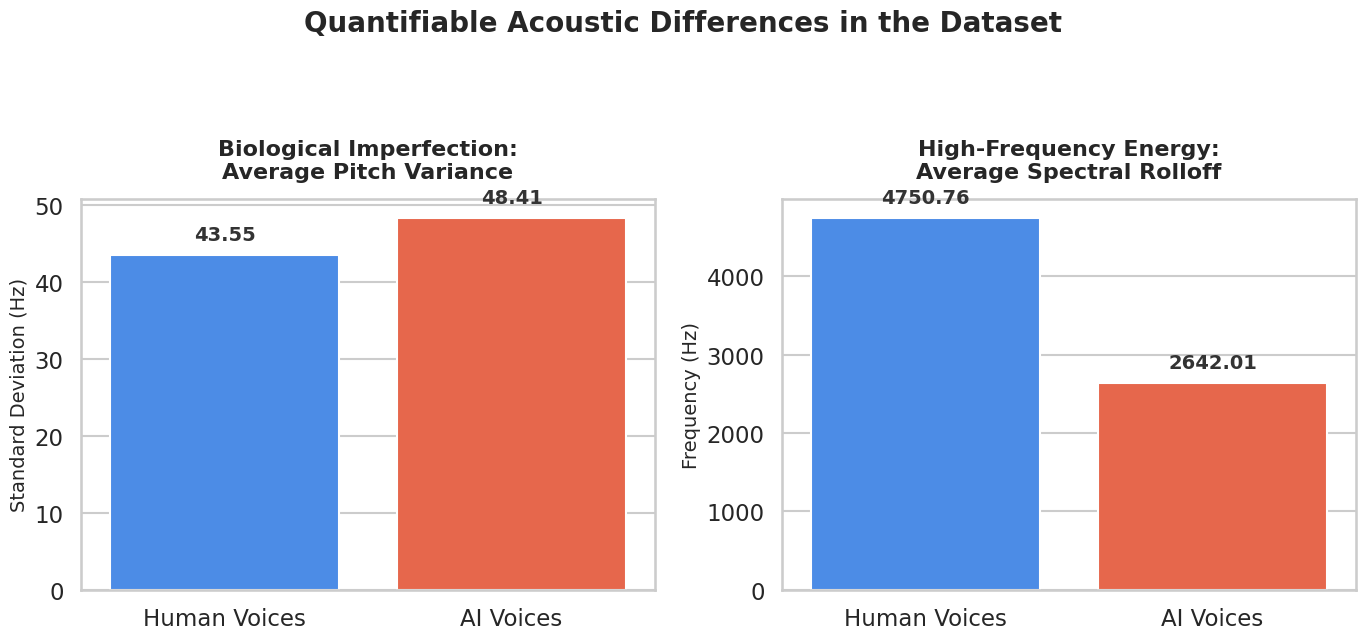

In [37]:

# Set a clean, professional theme for the presentation
sns.set_theme(style="whitegrid", context="talk")

# 1. Gather the data from the previous cell's variables
# We use np.mean() on the lists we generated earlier
categories = ['Human Voices', 'AI Voices']
pitch_means = [np.mean(human_pitch_stds), np.mean(ai_pitch_stds)]
rolloff_means = [np.mean(human_rolloffs), np.mean(ai_rolloffs)]

# 2. Create a figure with 2 subplots (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define colors matching your earlier t-SNE plot (Blue for Human, Orange/Red for AI)
custom_palette = ['#3388FF', '#FF5733']

# --- Plot 1: Pitch Variance ---
sns.barplot(x=categories, y=pitch_means, palette=custom_palette, ax=axes[0])
axes[0].set_title('Biological Imperfection:\nAverage Pitch Variance', fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('Standard Deviation (Hz)', fontsize=14)

# --- Plot 2: Spectral Rolloff ---
sns.barplot(x=categories, y=rolloff_means, palette=custom_palette, ax=axes[1])
axes[1].set_title('High-Frequency Energy:\nAverage Spectral Rolloff', fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('Frequency (Hz)', fontsize=14)

# 3. Add the exact numbers on top of the bars for maximum clarity
for ax in axes:
    for p in ax.patches:
        height = p.get_height()
        # Add the text annotation
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=14, fontweight='bold', color='#333333',
                    xytext=(0, 8), textcoords='offset points')

# Add a main title for the whole graphic
plt.suptitle('Quantifiable Acoustic Differences in the Dataset', fontsize=20, fontweight='heavy', y=1.08)

# Adjust layout and display
plt.tight_layout()
plt.show()